## Lots of Plots 

In [53]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import pypsa

try:
    import pycountry
except Exception:
    pycountry = None


def _normalize_country_iso2(value):
    if value is None:
        return None

    raw = str(value).strip()
    if not raw:
        return None

    aliases = {"UK": "GB"}
    upper = aliases.get(raw.upper(), raw.upper())

    if pycountry is not None:
        by_a2 = pycountry.countries.get(alpha_2=upper)
        if by_a2:
            return by_a2.alpha_2

        by_a3 = pycountry.countries.get(alpha_3=upper)
        if by_a3:
            return by_a3.alpha_2

        by_name = pycountry.countries.get(name=raw)
        if by_name:
            return by_name.alpha_2

        try:
            fuzzy = pycountry.countries.search_fuzzy(raw)
            if fuzzy:
                return fuzzy[0].alpha_2
        except Exception:
            pass

    if len(upper) == 2 and upper.isalpha():
        return upper

    return None


def _iso2_to_name(iso2):
    if not iso2:
        return "Model Area"
    if pycountry is None:
        return iso2
    c = pycountry.countries.get(alpha_2=str(iso2).upper())
    return c.name if c else str(iso2).upper()


def _iso2_to_iso3(iso2):
    if not iso2 or pycountry is None:
        return None
    c = pycountry.countries.get(alpha_2=str(iso2).upper())
    return c.alpha_3 if c else None


def _extract_iso2_from_path(network_path):
    if not network_path:
        return None

    p = Path(network_path)
    search_parts = list(p.parts) + [p.stem]

    for part in search_parts:
        for token in re.split(r"[^A-Za-z0-9]+", part):
            if not token:
                continue
            iso2 = _normalize_country_iso2(token)
            if iso2:
                return iso2

    return None


def _infer_target_country(network, network_path=None):
    # Prefer explicit metadata from the network, then filename/path hints, then bus-majority fallback.
    meta = getattr(network, "meta", None)
    if isinstance(meta, dict):
        meta_countries = meta.get("countries")
        if isinstance(meta_countries, (list, tuple)) and meta_countries:
            iso2 = _normalize_country_iso2(meta_countries[0])
            if iso2:
                return iso2, "network.meta['countries']"

    iso2_from_path = _extract_iso2_from_path(network_path)
    if iso2_from_path:
        return iso2_from_path, "network path"

    if "country" in network.buses.columns:
        countries = network.buses["country"].dropna().astype(str).str.upper()
        countries = countries[countries != ""]
        if not countries.empty:
            return countries.value_counts().idxmax(), "network.buses['country'] majority"

    return None, "unresolved"


def _select_country_shape(country_shapes, iso2=None, iso3=None, country_name=None):
    if country_shapes.empty:
        return country_shapes

    checks = [
        ("name", iso2),
        ("country", iso2),
        ("iso2", iso2),
        ("ISO2", iso2),
        ("iso_a2", iso2),
        ("ISO_A2", iso2),
        ("adm0_a3", iso3),
        ("ADM0_A3", iso3),
        ("iso3", iso3),
        ("ISO3", iso3),
    ]
    for col, val in checks:
        if val and col in country_shapes.columns:
            mask = country_shapes[col].astype(str).str.upper().eq(str(val).upper())
            out = country_shapes[mask]
            if not out.empty:
                return out

    # Try robust name matching for shape files that store long-form names.
    name_columns = [
        "name",
        "NAME",
        "name_long",
        "NAME_LONG",
        "admin",
        "ADMIN",
        "country",
        "COUNTRY",
    ]

    name_candidates = []
    if country_name:
        name_candidates.append(str(country_name))
    if iso2:
        iso2_name = _iso2_to_name(iso2)
        if iso2_name:
            name_candidates.append(str(iso2_name))
        if pycountry is not None:
            c = pycountry.countries.get(alpha_2=str(iso2).upper())
            if c is not None:
                for attr in ["name", "official_name", "common_name"]:
                    v = getattr(c, attr, None)
                    if v:
                        name_candidates.append(str(v))

    def _norm_name(value):
        return re.sub(r"[^a-z0-9]", "", str(value).lower())

    norm_candidates = {_norm_name(v) for v in name_candidates if str(v).strip()}

    for col in name_columns:
        if col not in country_shapes.columns or not norm_candidates:
            continue
        series = country_shapes[col].fillna("").astype(str)
        norm_series = series.map(_norm_name)

        for cand in norm_candidates:
            exact = country_shapes[norm_series.eq(cand)]
            if not exact.empty:
                return exact

            # Allow long-form names like "UnitedStatesOfAmerica" when candidate is "UnitedStates".
            if len(cand) >= 6:
                contains = country_shapes[norm_series.str.contains(cand, na=False)]
                if not contains.empty:
                    return contains

    return country_shapes.iloc[0:0]


def _find_reference_csv(iso2=None, iso3=None, year="2018"):
    keys = [k.lower() for k in [iso2, iso3] if k]
    roots = [Path("../shotton/data"), Path("data")]

    for root in roots:
        if not root.exists():
            continue
        candidates = []
        for key in keys:
            candidates.extend(
                [
                    root / f"temp-file-{key}-{year}.csv",
                    root / f"temp-file-{key}.csv",
                    root / f"temp-file-{key}-full.csv",
                ]
            )
        for c in candidates:
            if c.exists():
                return c

    return None


def _load_network_with_fallback(preferred_path, root=Path("../saved")):
    candidates = []
    if preferred_path:
        candidates.append(Path(preferred_path))
    candidates.extend(sorted(root.glob("*/*.nc"), reverse=True))

    tried = []
    for p in candidates:
        if not p.exists():
            continue
        try:
            return pypsa.Network(p), p
        except Exception as exc:
            tried.append((p, str(exc)))
            continue

    details = "\n".join([f"- {p}: {err}" for p, err in tried[:5]])
    raise FileNotFoundError(
        f"No loadable PyPSA network found under {root.resolve()}."
        + (f" Tried:\n{details}" if details else "")
    )


# Set the preferred network path; fallback discovery is automatic.
preferred_network_path = Path("../saved/US_test/elec_s_min_ec_lcopt_Co2L-3h.nc")
n, network_path = _load_network_with_fallback(preferred_network_path)

# Mirror aliases used by later cells so one change here updates all plots.
n_model = n
n_map = n
n_final = n

# Infer target country directly from network metadata/path, then bus data as fallback.
target_country_iso2, target_country_source = _infer_target_country(n, network_path)
target_country_iso3 = _iso2_to_iso3(target_country_iso2)
target_country_name = _iso2_to_name(target_country_iso2)

if target_country_iso2 and "country" in n.buses.columns:
    country_bus_idx = n.buses.index[
        n.buses["country"].astype(str).str.upper().eq(target_country_iso2)
    ]
else:
    country_bus_idx = n.buses.index

if country_bus_idx.empty:
    # Keep plots working even if bus country labels are missing/mismatched for the inferred country.
    country_bus_idx = n.buses.index

reference_path = _find_reference_csv(target_country_iso2, target_country_iso3)

bus_country_summary = None
if "country" in n.buses.columns:
    bus_country_summary = (
        n.buses["country"].dropna().astype(str).str.upper().value_counts().head(3).to_dict()
    )

print(f"Loaded network: {network_path}")
print(f"Snapshots: {len(n.snapshots)}")
print(f"Buses: {len(n.buses)} | Lines: {len(n.lines)} | Links: {len(n.links)}")
print(f"Target country: {target_country_name} ({target_country_iso2 or 'N/A'})")
print(f"Country inference source: {target_country_source}")
if bus_country_summary is not None:
    print(f"Top bus country labels: {bus_country_summary}")
print(f"Country buses in network selection: {len(country_bus_idx)}")
print(f"Reference CSV: {reference_path if reference_path else 'not found (model-only mode)'}")

Index(['1013 PHS', '10168 hydro', '10258 PHS', '1041 hydro', '10550 PHS',
       '10553 PHS', '10571 hydro', '10592 PHS', '10592 hydro', '10610 hydro',
       ...
       '9687 hydro', '9738 hydro', '9743 hydro', '9748 hydro', '9754 hydro',
       '9758 hydro', '9761 hydro', '9778 hydro', '9783 hydro', '9861 hydro'],
      dtype='object', name='name', length=396)
INFO:pypsa.io:Imported network elec_s_min_ec_lcopt_Co2L-6h.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


Loaded network: ../saved/US_test/elec_s_min_ec_lcopt_Co2L-6h.nc
Snapshots: 1460
Buses: 339 | Lines: 0 | Links: 547
Target country: United States (US)
Country inference source: network.meta['countries']
Top bus country labels: {'CN': 339}
Country buses in network selection: 339
Reference CSV: not found (model-only mode)


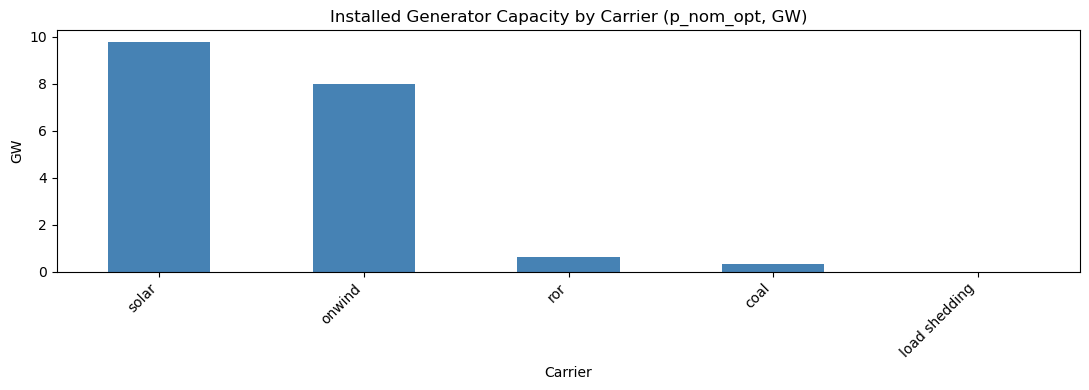

In [54]:
cap_col = "p_nom_opt" if "p_nom_opt" in n.generators.columns else "p_nom"
cap_by_carrier = (
    n.generators.groupby("carrier")[cap_col].sum().sort_values(ascending=False)
    / 1e3
)

fig, ax = plt.subplots(figsize=(11, 4))
cap_by_carrier.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title(f"Installed Generator Capacity by Carrier ({cap_col}, GW)")
ax.set_ylabel("GW")
ax.set_xlabel("Carrier")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

### Voronoi Subdivision Of Bus Regions
This reproduces the Voronoi partition approach used in the project code to split each country into nearest-bus service regions.

Voronoi cells are calculated from solved bus coordinates
Outline source (panel 3): data/gadm/gadm41_CHN/gadm41_CHN.gpkg
Panel 1 raw buses: 1574
Panel 2 LV buses: 1176
Panel 3 solved buses / unique coords (United States): 339/113


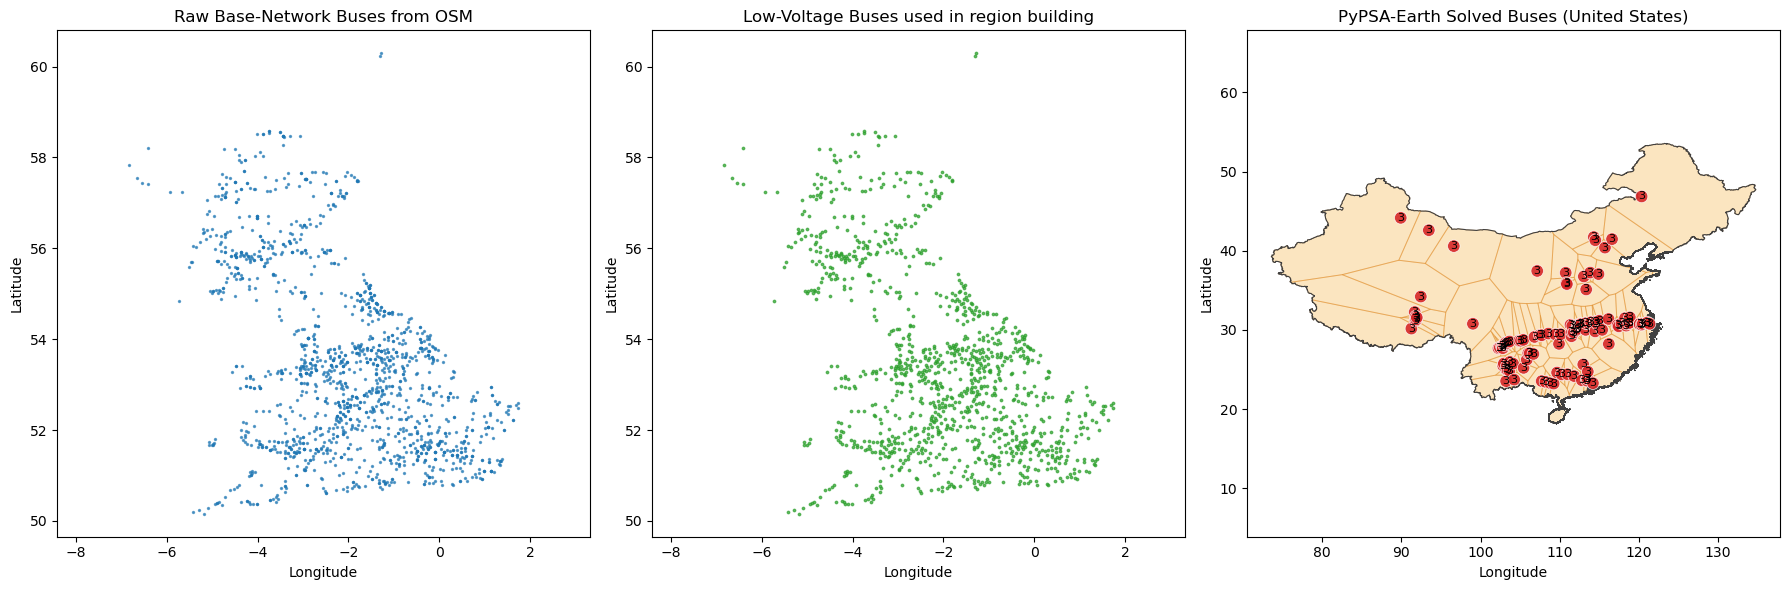

In [59]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pypsa
from scipy.spatial import Voronoi
from shapely.geometry import MultiPoint, Polygon

print("====================================================")
print("Voronoi cells are calculated from solved bus coordinates")
print("====================================================")

# 1) Pre-solve raw buses from base_network outputs
raw_buses = gpd.read_file("../resources/base_network/all_buses_build_network.geojson")
raw_buses = raw_buses[raw_buses.geometry.notna()]

# 2) LV substations used for region building
if "substation_lv" in raw_buses.columns:
    lv_buses = raw_buses[raw_buses["substation_lv"].fillna(False)]
else:
    lv_buses = raw_buses.copy()

# 3) Final solved network buses (reuse the network loaded in Cell 2).
if "n" in globals():
    n_final = n
elif "network_path" in globals():
    n_final = pypsa.Network(network_path)
else:
    raise NameError("Run Cell 2 first so network variables are defined.")

if "country_bus_idx" in globals() and len(country_bus_idx) > 0:
    final_buses = n_final.buses.loc[n_final.buses.index.intersection(country_bus_idx)]
else:
    final_buses = n_final.buses

final_buses = final_buses.dropna(subset=["x", "y"]).copy()
final_counts = final_buses.groupby(["x", "y"]).size().rename("count").reset_index()

# Country outline from shapes, inferred from the selected network country.
country_shapes = gpd.read_file("../resources/shapes/country_shapes.geojson")
country_outline = _select_country_shape(
    country_shapes,
    target_country_iso2 if "target_country_iso2" in globals() else None,
    target_country_iso3 if "target_country_iso3" in globals() else None,
    target_country_name if "target_country_name" in globals() else None,
)
outline_source = "resources/shapes/country_shapes.geojson"


def _load_gadm_country_outline(iso3):
    if not iso3:
        return gpd.GeoDataFrame()
    gadm_path = Path(f"../data/gadm/gadm41_{iso3}/gadm41_{iso3}.gpkg")
    if not gadm_path.exists():
        return gpd.GeoDataFrame()
    gdf = gpd.read_file(gadm_path, layer="ADM_ADM_0")
    if gdf.empty:
        return gdf
    # Merge admin regions to a single national outline.
    gdf = gdf[["geometry"]].dissolve().reset_index(drop=True)
    return gdf


if country_outline.empty and "target_country_iso3" in globals() and target_country_iso3:
    country_outline = _load_gadm_country_outline(target_country_iso3)
    if not country_outline.empty:
        outline_source = f"data/gadm/gadm41_{target_country_iso3}/gadm41_{target_country_iso3}.gpkg"

bus_majority_iso2 = None
if "country" in n_final.buses.columns:
    bus_majority = n_final.buses["country"].dropna().astype(str).str.upper().value_counts()
    if not bus_majority.empty:
        bus_majority_iso2 = bus_majority.index[0]

bus_majority_iso3 = _iso2_to_iso3(bus_majority_iso2) if bus_majority_iso2 else None
if country_outline.empty and bus_majority_iso3:
    country_outline = _load_gadm_country_outline(bus_majority_iso3)
    if not country_outline.empty:
        outline_source = (
            f"data/gadm/gadm41_{bus_majority_iso3}/gadm41_{bus_majority_iso3}.gpkg"
        )

# Fallback: build a convex hull around selected bus coordinates.
if country_outline.empty and not final_buses.empty:
    hull = MultiPoint(final_buses[["x", "y"]].to_numpy()).convex_hull.buffer(0.1)
    country_outline = gpd.GeoDataFrame({"geometry": [hull]}, crs="EPSG:4326")
    outline_source = "convex hull fallback"

print(f"Outline source (panel 3): {outline_source}")

if not country_outline.empty:
    if hasattr(country_outline, "union_all"):
        country_geom = country_outline.union_all()
    else:
        country_geom = country_outline.unary_union
else:
    country_geom = None


def clipped_voronoi_cells(points, outline=None, multiplier=5):
    points = np.asarray(points)
    if len(points) == 0:
        return []
    if len(points) == 1:
        return [outline] if outline is not None else []

    xmin, ymin = np.amin(points, axis=0)
    xmax, ymax = np.amax(points, axis=0)

    if outline is not None and not outline.is_empty:
        minx_o, miny_o, maxx_o, maxy_o = outline.boundary.bounds
        xmin = min(xmin, minx_o)
        ymin = min(ymin, miny_o)
        xmax = max(xmax, maxx_o)
        ymax = max(ymax, maxy_o)

    xspan = max(xmax - xmin, 1e-6)
    yspan = max(ymax - ymin, 1e-6)

    vor = Voronoi(
        np.vstack(
            (
                points,
                [
                    [xmin - multiplier * xspan, ymin - multiplier * yspan],
                    [xmin - multiplier * xspan, ymax + multiplier * yspan],
                    [xmax + multiplier * xspan, ymin - multiplier * yspan],
                    [xmax + multiplier * xspan, ymax + multiplier * yspan],
                ],
            )
        )
    )

    cells = []
    for i in range(len(points)):
        poly = Polygon(vor.vertices[vor.regions[vor.point_region[i]]])
        if not poly.is_valid:
            poly = poly.buffer(0)
        if outline is not None and not outline.is_empty:
            poly = poly.intersection(outline)
        cells.append(poly)

    return cells


vor_cells = clipped_voronoi_cells(final_counts[["x", "y"]].to_numpy(), country_geom)
crs = country_outline.crs if not country_outline.empty else None
voronoi_gdf = gpd.GeoDataFrame({"geometry": vor_cells}, crs=crs)
voronoi_gdf = voronoi_gdf[
    voronoi_gdf.geometry.notna()
    & voronoi_gdf.geometry.is_valid
    & ~voronoi_gdf.geometry.is_empty
]

country_label = target_country_name if "target_country_name" in globals() else "Selected Country"
print(f"Panel 1 raw buses: {len(raw_buses)}")
print(f"Panel 2 LV buses: {len(lv_buses)}")
print(f"Panel 3 solved buses / unique coords ({country_label}): {len(final_buses)}/{len(final_counts)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

raw_buses.plot(ax=axes[0], markersize=2, color="tab:blue", alpha=0.65)
axes[0].set_title("Raw Base-Network Buses from OSM")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

lv_buses.plot(ax=axes[1], markersize=3, color="tab:green", alpha=0.7)
axes[1].set_title("Low-Voltage Buses used in region building")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

if not voronoi_gdf.empty:
    voronoi_gdf.plot(
        ax=axes[2],
        facecolor="#f6b64c",
        edgecolor="#d97706",
        alpha=0.35,
        linewidth=0.7,
        zorder=1,
    )

if not country_outline.empty:
    country_outline.boundary.plot(ax=axes[2], color="0.25", linewidth=0.8, zorder=2)

axes[2].scatter(
    final_counts["x"],
    final_counts["y"],
    s=20 + 35 * np.sqrt(final_counts["count"]),
    color="tab:red",
    alpha=0.9,
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
)
for _, r in final_counts[final_counts["count"] > 1].iterrows():
    axes[2].text(r["x"], r["y"], str(int(r["count"])), fontsize=8, ha="center", va="center")
axes[2].set_title(f"PyPSA-Earth Solved Buses ({country_label})")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")

for ax in axes.ravel():
    ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()

Model snapshot years: [2023]
Country buses used (United States): 339
Reference panel available: False


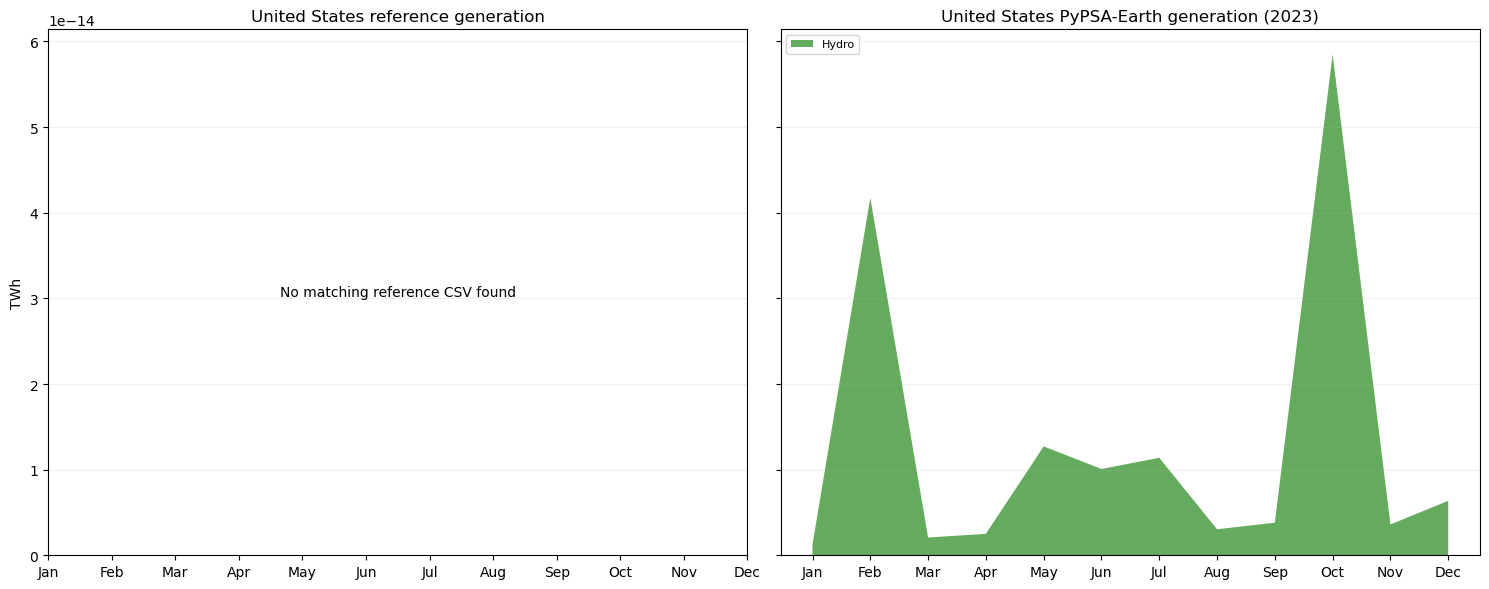

In [55]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pypsa

# Reuse the notebook's selected network from Cell 2.
if "n" in globals():
    n_model = n
elif "network_path" in globals():
    n_model = pypsa.Network(network_path)
else:
    raise NameError("Run Cell 2 first so network variables are defined.")

country_label = target_country_name if "target_country_name" in globals() else "Selected Country"
country_iso2 = target_country_iso2 if "target_country_iso2" in globals() else None
country_iso3 = target_country_iso3 if "target_country_iso3" in globals() else None

if "country_bus_idx" in globals() and len(country_bus_idx) > 0:
    country_buses = n_model.buses.index.intersection(country_bus_idx)
elif "country" in n_model.buses.columns and country_iso2:
    country_buses = n_model.buses.index[
        n_model.buses["country"].astype(str).str.upper().eq(country_iso2)
    ]
else:
    country_buses = n_model.buses.index

model_years = sorted(pd.Index(n_model.snapshots.year).unique())
print("Model snapshot years:", model_years)
print(f"Country buses used ({country_label}):", len(country_buses))

carrier_map = {
    "onwind": "Wind",
    "offwind-ac": "Wind",
    "offwind-dc": "Wind",
    "solar": "Solar",
    "solar rooftop": "Solar",
    "hydro": "Hydro",
    "ror": "Hydro",
    "nuclear": "Nuclear",
    "biomass": "Bioenergy",
    "CCGT": "Gas",
    "OCGT": "Gas",
    "coal": "Coal",
    "lignite": "Coal",
    "oil": "Other Fossil",
}

gen_p = n_model.generators_t.p.loc[:, n_model.generators.bus.isin(country_buses)]
gen_weights = n_model.snapshot_weightings.generators.reindex(gen_p.index)
gen_energy = gen_p.mul(gen_weights, axis=0)
gen_groups = n_model.generators.loc[gen_p.columns, "carrier"].map(carrier_map).fillna(
    n_model.generators.loc[gen_p.columns, "carrier"]
)
model_generation = gen_energy.T.groupby(gen_groups).sum().T

if not n_model.storage_units.empty:
    su = n_model.storage_units[n_model.storage_units.bus.isin(country_buses)].copy()
    su = su[su.carrier.isin(["hydro", "ror"])]
    if not su.empty:
        su_p = n_model.storage_units_t.p.loc[:, su.index].clip(lower=0)
        su_weights = n_model.snapshot_weightings.generators.reindex(su_p.index)
        su_energy = su_p.mul(su_weights, axis=0)
        su_groups = su["carrier"].map(carrier_map).fillna(su["carrier"])
        su_generation = su_energy.T.groupby(su_groups).sum().T
        model_generation = pd.concat([model_generation, su_generation], axis=1)
        model_generation = model_generation.T.groupby(level=0).sum().T

month_order = list(range(1, 13))
month_labels = pd.Index(pd.date_range("2000-01-01", periods=12, freq="MS").strftime("%b"))
model_month = model_generation.groupby(model_generation.index.month).sum().reindex(month_order, fill_value=0) / 1e6
model_month.index = month_labels

# Optional reference panel if a matching country CSV exists.
reference_available = False
reference_month = pd.DataFrame(index=month_labels)
if "reference_path" in globals() and reference_path and Path(reference_path).exists():
    reference = pd.read_csv(reference_path, parse_dates=["full_date"])

    if "entity_code" in reference.columns:
        codes = [c for c in [country_iso3, country_iso2] if c]
        ref_country = reference[reference["entity_code"].astype(str).str.upper().isin([c.upper() for c in codes])]
    else:
        ref_country = reference.copy()

    if not ref_country.empty and {"series", "generation_twh"}.issubset(ref_country.columns):
        reference_generation = ref_country[
            (~ref_country.get("is_aggregate_series", False))
            & (ref_country["series"] != "Total generation")
        ][["full_date", "series", "generation_twh"]].copy()

        series_name_map = {"Other fossil": "Other Fossil"}
        reference_generation["series"] = reference_generation["series"].replace(series_name_map)
        reference_generation = reference_generation.pivot_table(
            index="full_date", columns="series", values="generation_twh", aggfunc="sum"
        ).sort_index()

        reference_month = (
            reference_generation.groupby(reference_generation.index.month)
            .sum()
            .reindex(month_order, fill_value=0)
        )
        reference_month.index = month_labels
        reference_available = True

print("Reference panel available:", reference_available)

colors = {
    "Wind": "#4c78a8",
    "Solar": "#f2be3e",
    "Hydro": "#54a24b",
    "Nuclear": "#9c755f",
    "Bioenergy": "#72b7b2",
    "Gas": "#e45756",
    "Coal": "#4d4d4d",
    "Other Fossil": "#b279a2",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
x = range(len(month_labels))

if reference_available:
    reference_cols = [c for c in colors if c in reference_month.columns and reference_month[c].sum() > 0]
    if reference_cols:
        axes[0].stackplot(
            x,
            *[reference_month[c].values for c in reference_cols],
            labels=reference_cols,
            colors=[colors[c] for c in reference_cols],
            alpha=0.9,
        )
    axes[0].set_title(f"{country_label} reference generation")
    axes[0].legend(loc="upper left", ncol=4, fontsize=8)
else:
    axes[0].text(0.5, 0.5, "No matching reference CSV found", ha="center", va="center", transform=axes[0].transAxes)
    axes[0].set_title(f"{country_label} reference generation")

axes[0].set_ylabel("TWh")
axes[0].set_xticks(list(x), month_labels)

model_cols = [c for c in colors if c in model_month.columns and model_month[c].sum() > 0]
extra_model_cols = [c for c in model_month.columns if c not in colors and model_month[c].sum() > 0]
all_model_cols = model_cols + extra_model_cols
model_colors = [colors.get(c, "#bab0ab") for c in all_model_cols]
if all_model_cols:
    axes[1].stackplot(
        x,
        *[model_month[c].values for c in all_model_cols],
        labels=all_model_cols,
        colors=model_colors,
        alpha=0.9,
    )
    axes[1].legend(loc="upper left", ncol=4, fontsize=8)

axes[1].set_title(f"{country_label} PyPSA-Earth generation ({', '.join(map(str, model_years))})")
axes[1].set_xticks(list(x), month_labels)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

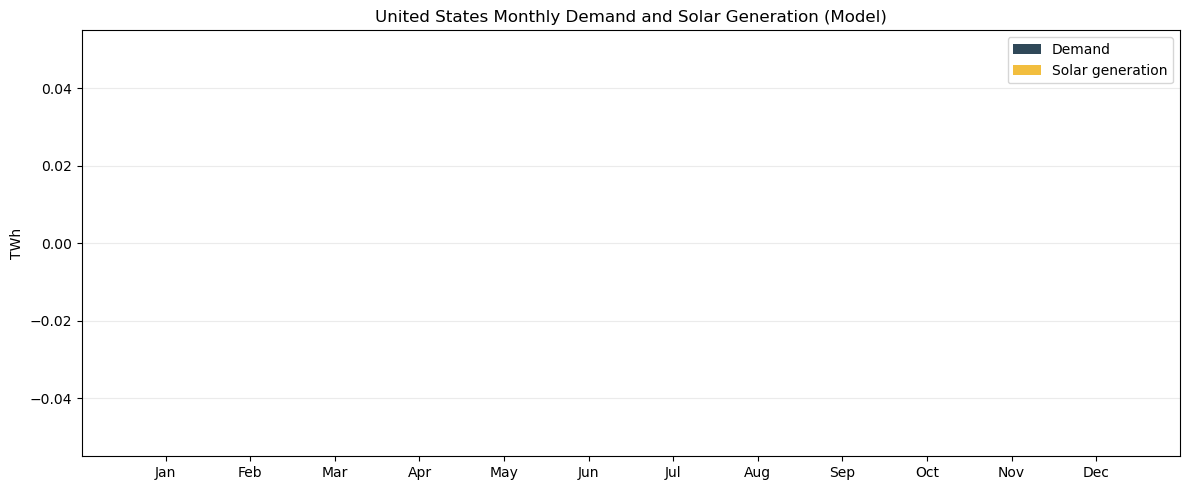

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

# Model-only monthly demand and solar generation for the selected country.
if "n_model" in globals():
    n_plot = n_model
elif "n" in globals():
    n_plot = n
elif "network_path" in globals():
    n_plot = pypsa.Network(network_path)
else:
    raise NameError("Run Cell 2 first so network variables are defined.")

country_label = target_country_name if "target_country_name" in globals() else "Selected Country"

if "country_bus_idx" in globals() and len(country_bus_idx) > 0:
    buses = n_plot.buses.index.intersection(country_bus_idx)
else:
    buses = n_plot.buses.index

weights = n_plot.snapshot_weightings.generators.reindex(n_plot.snapshots).fillna(1.0)

# Demand [TWh/month]
load_idx = n_plot.loads.index[n_plot.loads.bus.isin(buses)]
if len(load_idx) > 0:
    load_col = "p" if "p" in n_plot.loads_t and not n_plot.loads_t.p.empty else "p_set"
    demand_ts = getattr(n_plot.loads_t, load_col).reindex(columns=load_idx, fill_value=0.0).sum(axis=1)
    demand_twh = demand_ts.mul(weights, axis=0) / 1e6
    demand_month = demand_twh.groupby(demand_twh.index.month).sum().reindex(range(1, 13), fill_value=0.0)
else:
    demand_month = pd.Series(0.0, index=range(1, 13))

# Solar generation [TWh/month]
solar_carriers = ["solar", "solar rooftop"]
solar_idx = n_plot.generators.index[
    n_plot.generators.bus.isin(buses) & n_plot.generators.carrier.isin(solar_carriers)
]
if len(solar_idx) > 0:
    solar_ts = n_plot.generators_t.p.reindex(columns=solar_idx, fill_value=0.0).sum(axis=1)
    solar_twh = solar_ts.mul(weights, axis=0) / 1e6
    solar_month = solar_twh.groupby(solar_twh.index.month).sum().reindex(range(1, 13), fill_value=0.0)
else:
    solar_month = pd.Series(0.0, index=range(1, 13))

plot_df = pd.DataFrame(
    {
        "Demand": demand_month.values,
        "Solar Generation": solar_month.values,
    },
    index=pd.Index(pd.date_range("2000-01-01", periods=12, freq="MS").strftime("%b"), name="Month"),
)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(plot_df.index))

lower_color = "#2f4858"
solar_orange = "#f2be3e"

ax.bar(x, plot_df["Demand"], color=lower_color, label="Demand")
ax.bar(
    x,
    plot_df["Solar Generation"],
    bottom=plot_df["Demand"],
    color=solar_orange,
    label="Solar generation",
)

ax.set_xticks(list(x), plot_df.index)
ax.set_ylabel("TWh")
ax.set_title(f"{country_label} Monthly Demand and Solar Generation (Model)")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

Nodes plotted: 113
Annual solar generation allocated: 0.00 TWh


,node_label,x,y,bus_count,allocation_share,allocated_twh
0,N1,102.2621,27.6868,3,0.0088,0.0
1,N2,112.6993,30.7171,3,0.0088,0.0
2,N3,116.2073,28.2218,3,0.0088,0.0
3,N4,116.1697,31.3784,3,0.0088,0.0
4,N5,115.7179,40.3967,3,0.0088,0.0
...,...,...,...,...,...,...
108,N109,108.5689,29.5392,3,0.0088,0.0
109,N110,108.1985,23.4457,3,0.0088,0.0
110,N111,107.7393,29.3312,3,0.0088,0.0
111,N112,107.7281,23.5317,3,0.0088,0.0


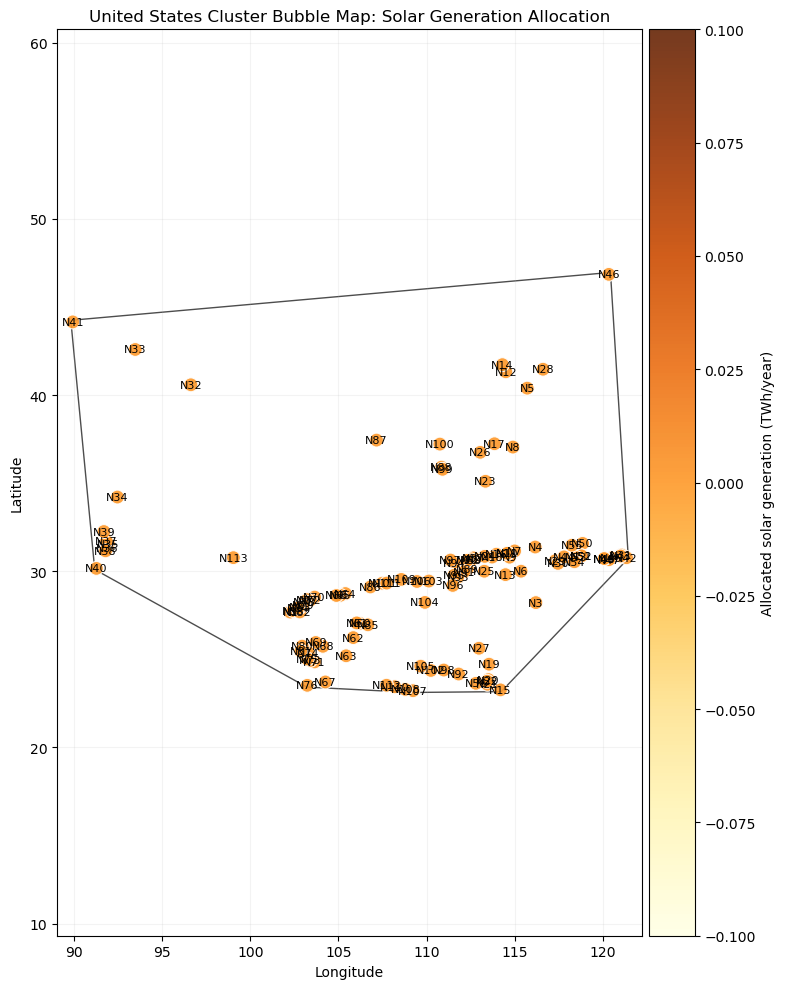

In [57]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import pypsa
from shapely.geometry import MultiPoint

# 1) Load solved network (prefer already-loaded object).
if "n_model" in globals():
    n_map = n_model
elif "n" in globals():
    n_map = n
else:
    def _find_solved_nc(root=Path("../saved"), preferred_year="2018"):
        files = sorted(root.glob("*/*.nc"))
        if not files:
            raise FileNotFoundError(f"No solved .nc found under {root.resolve()}")
        preferred = [p for p in files if preferred_year in p.parts]
        return preferred[0] if preferred else files[-1]

    n_map = pypsa.Network(_find_solved_nc(preferred_year="2018"))

country_label = target_country_name if "target_country_name" in globals() else "Selected Country"

# 2) Build country node table (cluster nodes represented by unique solved bus coordinates).
if "country_bus_idx" in globals() and len(country_bus_idx) > 0:
    country_buses = n_map.buses.loc[n_map.buses.index.intersection(country_bus_idx)]
else:
    country_buses = n_map.buses

country_buses = country_buses.dropna(subset=["x", "y"]).copy()
if country_buses.empty:
    raise ValueError("No buses with coordinates found for the selected country.")

country_buses["node_key"] = country_buses["x"].round(5).astype(str) + "|" + country_buses["y"].round(5).astype(str)
nodes = country_buses.groupby("node_key", as_index=False).agg(
    x=("x", "first"),
    y=("y", "first"),
    bus_count=("x", "size"),
)

# 3) Compute annual node metric from the selected network.
weights = n_map.snapshot_weightings.generators.reindex(n_map.snapshots).fillna(1.0)

solar_carriers = ["solar", "solar rooftop"]
solar_idx = n_map.generators.index[
    n_map.generators.bus.isin(country_buses.index) & n_map.generators.carrier.isin(solar_carriers)
]

if len(solar_idx) > 0:
    metric_label = "solar generation"
    metric_col = "metric_twh"
    gen_energy = n_map.generators_t.p.reindex(columns=solar_idx, fill_value=0.0).mul(weights, axis=0) / 1e6
    gen_bus = n_map.generators.loc[solar_idx, "bus"]
    metric_by_bus = gen_energy.T.groupby(gen_bus).sum().sum(axis=1)
else:
    all_idx = n_map.generators.index[n_map.generators.bus.isin(country_buses.index)]
    metric_label = "total generation"
    metric_col = "metric_twh"
    if len(all_idx) > 0:
        gen_energy = n_map.generators_t.p.reindex(columns=all_idx, fill_value=0.0).mul(weights, axis=0) / 1e6
        gen_bus = n_map.generators.loc[all_idx, "bus"]
        metric_by_bus = gen_energy.T.groupby(gen_bus).sum().sum(axis=1)
    else:
        metric_by_bus = pd.Series(dtype=float)

bus_to_node = country_buses["node_key"]
metric_by_node = metric_by_bus.groupby(bus_to_node.reindex(metric_by_bus.index)).sum() if not metric_by_bus.empty else pd.Series(dtype=float)

nodes = nodes.set_index("node_key")
nodes[metric_col] = metric_by_node.reindex(nodes.index).fillna(0.0)

total_metric_twh = float(nodes[metric_col].sum())
if total_metric_twh > 0:
    nodes["allocation_share"] = nodes[metric_col] / total_metric_twh
else:
    nodes["allocation_share"] = 1.0 / len(nodes)

nodes["allocated_twh"] = nodes["allocation_share"] * total_metric_twh
nodes = nodes.reset_index().sort_values("allocated_twh", ascending=False).reset_index(drop=True)
nodes["node_label"] = [f"N{i+1}" for i in range(len(nodes))]

# 4) Plot bubble map with dynamic country outline.
country_shapes = gpd.read_file("../resources/shapes/country_shapes.geojson")
country_outline = _select_country_shape(
    country_shapes,
    target_country_iso2 if "target_country_iso2" in globals() else None,
    target_country_iso3 if "target_country_iso3" in globals() else None,
    target_country_name if "target_country_name" in globals() else None,
)

# Fallback: convex hull from selected bus coordinates.
if country_outline.empty and not country_buses.empty:
    hull = MultiPoint(country_buses[["x", "y"]].to_numpy()).convex_hull.buffer(0.1)
    country_outline = gpd.GeoDataFrame({"geometry": [hull]}, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 10))
if not country_outline.empty:
    country_outline.boundary.plot(ax=ax, color="0.3", linewidth=1.0, zorder=1)

size_scale = 1800
sizes = 100 + size_scale * nodes["allocated_twh"] / max(nodes["allocated_twh"].max(), 1e-9)
sc = ax.scatter(
    nodes["x"],
    nodes["y"],
    s=sizes,
    c=nodes["allocated_twh"],
    cmap="YlOrBr",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    zorder=3,
)

for _, row in nodes.iterrows():
    ax.text(row["x"], row["y"], row["node_label"], fontsize=8, ha="center", va="center", zorder=4)

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label(f"Allocated {metric_label} (TWh/year)")

ax.set_title(f"{country_label} Cluster Bubble Map: {metric_label.title()} Allocation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.15)
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()

print(f"Nodes plotted: {len(nodes)}")
print(f"Annual {metric_label} allocated: {total_metric_twh:.2f} TWh")
display(nodes[["node_label", "x", "y", "bus_count", "allocation_share", "allocated_twh"]].round(4))

Plotting window: 2023-01-01 00:00:00  ->  2023-01-14 18:00:00  (56 snapshots)


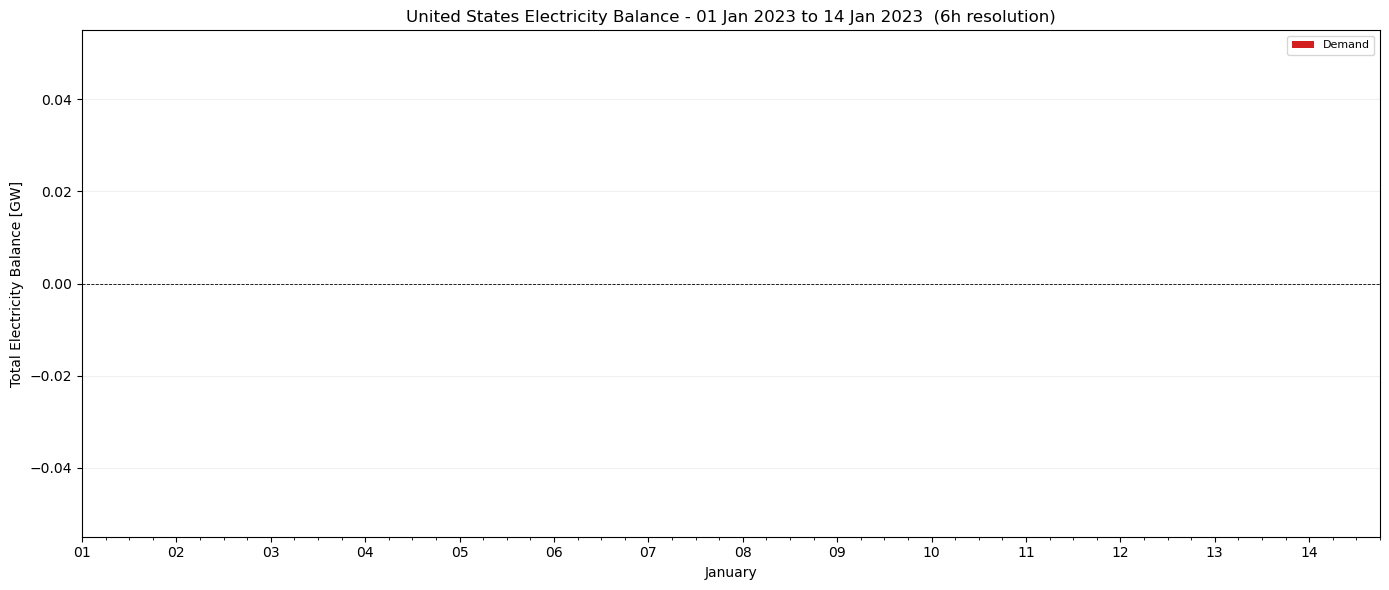

Snapshot resolution: 6h | snapshots in window: 56
Peak generation: 0.0 GW
Peak demand:     0.0 GW


In [58]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa

# ------------------------------------------------------------------
# Load network (reuse n_model / n_map if already in scope)
# ------------------------------------------------------------------
if "n_model" in globals():
    _n = n_model
elif "n_map" in globals():
    _n = n_map
elif "n" in globals():
    _n = n
else:
    def _find_nc(root=Path("../saved"), yr="2018"):
        files = sorted(root.glob("*/*.nc"))
        if not files:
            raise FileNotFoundError(f"No .nc files under {root.resolve()}")
        pref = [p for p in files if yr in p.parts]
        return pref[0] if pref else files[-1]
    _n = pypsa.Network(_find_nc())

country_label = target_country_name if "target_country_name" in globals() else "Selected Country"

if "country_bus_idx" in globals() and len(country_bus_idx) > 0:
    country_bus_idx_plot = _n.buses.index.intersection(country_bus_idx)
elif "target_country_iso2" in globals() and "country" in _n.buses.columns and target_country_iso2:
    country_bus_idx_plot = _n.buses.index[_n.buses["country"].astype(str).str.upper().eq(target_country_iso2)]
else:
    country_bus_idx_plot = _n.buses.index

if len(country_bus_idx_plot) == 0:
    raise ValueError("No buses found for selected country in this network.")

# ------------------------------------------------------------------
# Pick a 7-day window — change start_date to explore other periods
# ------------------------------------------------------------------
start_date = "2018-01-01"
end_date = "2018-01-08"

snaps = _n.snapshots
window = snaps[(snaps >= start_date) & (snaps < end_date)]
if len(window) == 0:
    # fall back to first 7 days of whatever year is present
    window = snaps[: min(56, len(snaps))]
print(f"Plotting window: {window[0]}  ->  {window[-1]}  ({len(window)} snapshots)")

# ------------------------------------------------------------------
# Carrier -> display-name + colour (extend as needed)
# ------------------------------------------------------------------
CARRIER_STYLE = {
    "CCGT": ("CCGT", "#8B0000"),
    "OCGT": ("OCGT", "#F4A9A8"),
    "onwind": ("Onshore wind", "#4c78a8"),
    "offwind-ac": ("Offshore wind", "#6aafd4"),
    "offwind-dc": ("Offshore wind", "#6aafd4"),
    "solar": ("Solar PV", "#f2be3e"),
    "nuclear": ("Nuclear", "#9c755f"),
    "hydro": ("Hydro", "#54a24b"),
    "ror": ("Hydro", "#54a24b"),
    "biomass": ("Biomass", "#72b7b2"),
    "coal": ("Coal", "#4d4d4d"),
    "lignite": ("Coal", "#4d4d4d"),
    "oil": ("Oil", "#b279a2"),
    "geothermal": ("Geothermal", "#e8825c"),
    "battery": ("Li-Ion battery", "#e040fb"),
    "H2": ("Hydrogen", "#aacc44"),
}


def _label_color(carrier):
    style = CARRIER_STYLE.get(carrier)
    if style:
        return style
    return (carrier, "#bab0ab")


# ------------------------------------------------------------------
# Generator dispatch [GW], positive
# ------------------------------------------------------------------
country_gens = _n.generators.index[_n.generators.bus.isin(country_bus_idx_plot)]
gen_p = _n.generators_t.p.reindex(columns=country_gens, fill_value=0.0).loc[window]
gen_carrier = _n.generators.loc[country_gens, "carrier"]

# collapse to display-name groups
pos_contrib = {}
for carrier, grp in gen_carrier.groupby(gen_carrier):
    label, color = _label_color(carrier)
    series = gen_p[grp.index].sum(axis=1) / 1e3  # MW -> GW
    if series.abs().max() < 1e-6:
        continue
    if label in pos_contrib:
        pos_contrib[label] = (pos_contrib[label][0] + series, color)
    else:
        pos_contrib[label] = (series, color)

# ------------------------------------------------------------------
# Storage units (positive = dispatch above zero, negative = charging below zero)
# ------------------------------------------------------------------
neg_storage = {}
if not _n.storage_units.empty:
    country_su = _n.storage_units.index[_n.storage_units.bus.isin(country_bus_idx_plot)]
    if len(country_su):
        su_p = _n.storage_units_t.p.reindex(columns=country_su, fill_value=0.0).loc[window]
        su_carrier = _n.storage_units.loc[country_su, "carrier"]
        for carrier, grp in su_carrier.groupby(su_carrier):
            label, color = _label_color(carrier)
            series = su_p[grp.index].sum(axis=1) / 1e3
            dispatch = series.clip(lower=0)
            charging = series.clip(upper=0)
            if dispatch.abs().max() > 1e-6:
                if label in pos_contrib:
                    pos_contrib[label] = (pos_contrib[label][0] + dispatch, color)
                else:
                    pos_contrib[label] = (dispatch, color)
            if charging.abs().max() > 1e-6:
                neg_storage[label] = (charging, color)

# ------------------------------------------------------------------
# Stores (battery, H2 — p > 0 = withdrawing from store = generation)
# ------------------------------------------------------------------
if not _n.stores.empty:
    country_st = _n.stores.index[_n.stores.bus.isin(country_bus_idx_plot)]
    if len(country_st):
        st_p = _n.stores_t.p.reindex(columns=country_st, fill_value=0.0).loc[window]
        st_carrier = _n.stores.loc[country_st, "carrier"]
        for carrier, grp in st_carrier.groupby(st_carrier):
            label, color = _label_color(carrier)
            series = st_p[grp.index].sum(axis=1) / 1e3
            dispatch = series.clip(lower=0)
            charging = series.clip(upper=0)
            if dispatch.abs().max() > 1e-6:
                if label in pos_contrib:
                    pos_contrib[label] = (pos_contrib[label][0] + dispatch, color)
                else:
                    pos_contrib[label] = (dispatch, color)
            if charging.abs().max() > 1e-6:
                neg_storage[label] = (charging, color)

# ------------------------------------------------------------------
# Demand [GW], negative
# ------------------------------------------------------------------
country_loads = _n.loads.index[_n.loads.bus.isin(country_bus_idx_plot)]
load_col = "p" if "p" in _n.loads_t and not _n.loads_t.p.empty else "p_set"
load_df = getattr(_n.loads_t, load_col).reindex(columns=country_loads, fill_value=0.0).loc[window]
demand_gw = load_df.sum(axis=1) / 1e3

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
t = window.to_pydatetime()

# --- positive stack (generation + storage dispatch) ---
ordered_pos = sorted(pos_contrib.items(), key=lambda x: -x[1][0].mean())
pos_labels = [k for k, _ in ordered_pos]
pos_arrays = [v[0].values for _, v in ordered_pos]
pos_colors = [v[1] for _, v in ordered_pos]

if pos_arrays:
    ax.stackplot(t, pos_arrays, labels=pos_labels, colors=pos_colors, alpha=0.88)

# --- negative stack (demand + storage charging) ---
neg_items = [("Demand", (-demand_gw, "#CC0000"))] + list(neg_storage.items())
neg_labels = [k for k, _ in neg_items]
neg_arrays = [v[0].values for _, v in neg_items]
neg_colors = [v[1] for _, v in neg_items]

if neg_arrays:
    ax.stackplot(t, neg_arrays, labels=neg_labels, colors=neg_colors, alpha=0.88)

ax.axhline(0, color="black", linewidth=0.6, linestyle="--", zorder=5)

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d"))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))

month_name = pd.Timestamp(window[0]).strftime("%B")
ax.set_xlabel(month_name)
ax.set_ylabel("Total Electricity Balance [GW]")
ax.set_title(
    f"{country_label} Electricity Balance - {window[0].strftime('%d %b %Y')} to {window[-1].strftime('%d %b %Y')}"
    f"  ({int((window[1]-window[0]).total_seconds()//3600)}h resolution)"
)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right", ncol=2, fontsize=8, framealpha=0.8)

ax.grid(axis="y", alpha=0.18)
ax.set_xlim(t[0], t[-1])
plt.tight_layout()
plt.show()

res_h = int((window[1] - window[0]).total_seconds() // 3600)
print(f"Snapshot resolution: {res_h}h | snapshots in window: {len(window)}")
print(f"Peak generation: {sum(a.max() for a in pos_arrays):.1f} GW")
print(f"Peak demand:     {demand_gw.max():.1f} GW")